### Uploading a Zip File

1.  **Run the code cell below**: This will prompt you to select a file from your local computer.
2.  **Select your `.zip` file**: A file dialog will open. Navigate to your zip file and select it.
3.  **Unzip the file**: Once the upload is complete, you can use the `unzip` command in a new code cell to extract the contents of the zip file into your Colab environment.

In [1]:
from google.colab import files
import os

# This will open a file picker for you to upload your zip file.
uploaded = files.upload()

# Get the name of the uploaded file
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  uploaded_zip_filename = fn

# Verify if a file was uploaded and try to unzip it
if 'uploaded_zip_filename' in locals():
  if uploaded_zip_filename.endswith('.zip'):
    print(f'Unzipping {uploaded_zip_filename}...')
    # Use the 'unzip' command to extract contents
    # The -q flag makes it quiet, -o overwrites existing files without prompting
    !unzip -q -o {uploaded_zip_filename}
    print('Files unzipped successfully.')
    print('Listing extracted files:')
    !ls -F
  else:
    print(f'The uploaded file "{uploaded_zip_filename}" is not a zip file. Please upload a .zip file.')
else:
  print('No file was uploaded.')

Saving Damage Propagation Modeling.pdf to Damage Propagation Modeling.pdf
Saving readme.txt to readme.txt
Saving RUL_FD001.txt to RUL_FD001.txt
Saving RUL_FD002.txt to RUL_FD002.txt
Saving RUL_FD003.txt to RUL_FD003.txt
Saving RUL_FD004.txt to RUL_FD004.txt
Saving test_FD001.txt to test_FD001.txt
Saving test_FD002.txt to test_FD002.txt
Saving test_FD003.txt to test_FD003.txt
Saving test_FD004.txt to test_FD004.txt
Saving train_FD001.txt to train_FD001.txt
Saving train_FD002.txt to train_FD002.txt
Saving train_FD003.txt to train_FD003.txt
Saving train_FD004.txt to train_FD004.txt
User uploaded file "Damage Propagation Modeling.pdf" with length 434158 bytes
User uploaded file "readme.txt" with length 2442 bytes
User uploaded file "RUL_FD001.txt" with length 429 bytes
User uploaded file "RUL_FD002.txt" with length 1110 bytes
User uploaded file "RUL_FD003.txt" with length 428 bytes
User uploaded file "RUL_FD004.txt" with length 1084 bytes
User uploaded file "test_FD001.txt" with length 222

In [8]:
print(f"Unique values in 'op_setting_3': {df_train_FD001['op_setting_3'].unique()}")
print(f"Number of unique values in 'op_setting_3': {df_train_FD001['op_setting_3'].nunique()}")

if df_train_FD001['op_setting_3'].nunique() == 1:
    print("As observed, 'op_setting_3' is constant. It provides no variance and can be dropped from the dataset if not needed for specific domain interpretation.")
else:
    print("The 'op_setting_3' column is not constant.")

KeyError: 'op_setting_3'

In [7]:
print(f"Unique values in 'op_setting_3': {df_train_FD001['op_setting_3'].unique()}")
print(f"Number of unique values in 'op_setting_3': {df_train_FD001['op_setting_3'].nunique()}")

if df_train_FD001['op_setting_3'].nunique() == 1:
    print("As observed, 'op_setting_3' is constant. It provides no variance and can be dropped from the dataset if not needed for specific domain interpretation.")
else:
    print("The 'op_setting_3' column is not constant.")

KeyError: 'op_setting_3'

In [6]:
import pandas as pd

# Define the path to the train_FD001.txt file
train_file_path = '/content/train_FD001.txt'

# Load the data into a pandas DataFrame
# The readme states the data is space-separated, so we use 'sep=\s+'
# Also, there are no headers in the file, so we set 'header=None'
df_train_FD001 = pd.read_csv(train_file_path, sep='\s+', header=None)

# Display the first 5 rows of the DataFrame
print(f'Successfully loaded {train_file_path}. Here are the first 5 rows:')
display(df_train_FD001.head())

Successfully loaded /content/train_FD001.txt. Here are the first 5 rows:


<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_275/2797489198.py:9: SyntaxWarning: invalid escape sequence '\s'
  df_train_FD001 = pd.read_csv(train_file_path, sep='\s+', header=None)


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


The `readme.txt` also specified the column descriptions. Let's assign proper column names to the DataFrame for better readability and easier analysis.

According to the `readme.txt`:
1) unit number
2) time, in cycles
3) operational setting 1
4) operational setting 2
5) operational setting 3
6) sensor measurement 1
... 26) sensor measurement 26

In [9]:
columns = [
    'unit_number', 'time_in_cycles',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

df_train_FD001.columns = columns

print('\nDataFrame with assigned column names:')
display(df_train_FD001.head())


DataFrame with assigned column names:


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [10]:
print(f"Unique values in 'op_setting_3': {df_train_FD001['op_setting_3'].unique()}")
print(f"Number of unique values in 'op_setting_3': {df_train_FD001['op_setting_3'].nunique()}")

if df_train_FD001['op_setting_3'].nunique() == 1:
    print("As observed, 'op_setting_3' is constant. It provides no variance and can be dropped from the dataset if not needed for specific domain interpretation.")
else:
    print("The 'op_setting_3' column is not constant.")

Unique values in 'op_setting_3': [100.]
Number of unique values in 'op_setting_3': 1
As observed, 'op_setting_3' is constant. It provides no variance and can be dropped from the dataset if not needed for specific domain interpretation.


In [11]:
# 1. Find the maximum cycle for each motor
max_cycle = train_df.groupby('unit_number')['time_cycle'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_of_unit']

# 2. Merge this max cycle back into the original dataframe
train_df = train_df.merge(max_cycle, on=['unit_number'], how='left')

# 3. Calculate RUL: (Max Cycle - Current Cycle)
train_df['RUL'] = train_df['max_of_unit'] - train_df['time_cycle']

# 4. Drop the helper column 'max_of_unit' as we don't need it anymore
train_df.drop('max_of_unit', axis=1, inplace=True)

print(train_df[['unit_number', 'time_cycle', 'RUL']].head())

NameError: name 'train_df' is not defined

In [14]:
# Make a copy to avoid modifying the original DataFrame directly if further operations are needed
df_train_FD001_rul = df_train_FD001.copy()

# 1. Find the maximum cycle for each motor
max_cycle = df_train_FD001_rul.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_of_unit']

# 2. Merge this max cycle back into the original dataframe
df_train_FD001_rul = df_train_FD001_rul.merge(max_cycle, on=['unit_number'], how='left')

# 3. Calculate RUL: (Max Cycle - Current Cycle)
df_train_FD001_rul['RUL'] = df_train_FD001_rul['max_of_unit'] - df_train_FD001_rul['time_in_cycles']

# 4. Drop the helper column 'max_of_unit' as we don't need it anymore
df_train_FD001_rul.drop('max_of_unit', axis=1, inplace=True)

print("DataFrame with RUL calculated (first 5 rows):")
display(df_train_FD001_rul[['unit_number', 'time_in_cycles', 'RUL']].head())

DataFrame with RUL calculated (first 5 rows):


,unit_number,time_in_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# We will work on a copy of df_train_FD001_rul to avoid modifying it directly
df_processed = df_train_FD001_rul.copy()

# 1. CLEANING: Identifying and dropping "Dead" sensors (those that never change)
# We calculate the standard deviation; if it's 0, the sensor is useless.
# Exclude 'unit_number', 'time_in_cycles', and 'RUL' from stats calculation
stats = df_processed.drop(columns=['unit_number', 'time_in_cycles', 'RUL']).describe().T
dead_sensors = stats[stats['std'] == 0].index.tolist()

# In FD001, 'op_setting_3' is also constant, as previously observed.
# We will add it to the list of columns to drop if not already there.
if 'op_setting_3' in df_processed.columns and 'op_setting_3' not in dead_sensors:
    dead_sensors.append('op_setting_3')

if dead_sensors:
    print(f"Dropping these constant sensors/settings: {dead_sensors}")
    df_processed.drop(columns=dead_sensors, inplace=True)
else:
    print("No constant sensors/settings found to drop.")

# 2. SCALING: Bringing all sensors to a scale of 0 to 1
# This ensures the model isn't biased toward sensors with naturally large numbers.
scaler = MinMaxScaler()

# We only scale the sensor and operational setting columns (not unit_number, time_in_cycles or RUL)
# Ensure 'RUL' is not in features list as it's the target
features = [col for col in df_processed.columns if col not in ['unit_number', 'time_in_cycles', 'RUL']]

df_processed[features] = scaler.fit_transform(df_processed[features])

# 3. SPLITTING: Dividing data into 'Features' (X) and 'Target' (y)
# X = The sensor and operational setting data (the clues)
# y = The RUL (the answer)
X = df_processed[features]
y = df_processed['RUL']

print("\n--- Data Preparation Complete ---")
print(f"Features being used: {features}")
print(f"Shape of features (X): {X.shape}")
print(f"Shape of labels (y): {y.shape}")
print("First 5 rows of X:")
display(X.head())
print("First 5 rows of y:")
display(y.head())

Dropping these constant sensors/settings: ['op_setting_3', 'sensor_18', 'sensor_19']

--- Data Preparation Complete ---
Features being used: ['op_setting_1', 'op_setting_2', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_20', 'sensor_21']
Shape of features (X): (20631, 21)
Shape of labels (y): (20631,)
First 5 rows of X:


,op_setting_1,op_setting_2,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_20,sensor_21
0,0.459770,0.166667,0.0,0.183735,0.406802,0.309757,0.0,1.0,0.726248,0.242424,...,0.0,0.369048,0.633262,0.205882,0.199608,0.363986,0.0,0.333333,0.713178,0.724662
1,0.609195,0.250000,0.0,0.283133,0.453019,0.352633,0.0,1.0,0.628019,0.212121,...,0.0,0.380952,0.765458,0.279412,0.162813,0.411312,0.0,0.333333,0.666667,0.731014
2,0.252874,0.750000,0.0,0.343373,0.369523,0.370527,0.0,1.0,0.710145,0.272727,...,0.0,0.250000,0.795309,0.220588,0.171793,0.357445,0.0,0.166667,0.627907,0.621375
3,0.540230,0.500000,0.0,0.343373,0.256159,0.331195,0.0,1.0,0.740741,0.318182,...,0.0,0.166667,0.889126,0.294118,0.174889,0.166603,0.0,0.333333,0.573643,0.662386
4,0.390805,0.333333,0.0,0.349398,0.257467,0.404625,0.0,1.0,0.668277,0.242424,...,0.0,0.255952,0.746269,0.235294,0.174734,0.402078,0.0,0.416667,0.589147,0.704502


First 5 rows of y:


,RUL
0,191
1,190
2,189
3,188
4,187


### 1. Splitting Data into Training and Testing Sets

To evaluate our model's performance on unseen data, we'll split our features (`X`) and target (`y`) into training and testing sets.

In [17]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16504, 21)
X_test shape: (4127, 21)
y_train shape: (16504,)
y_test shape: (4127,)


### 2. Training the Random Forest Regressor Model

We'll use `RandomForestRegressor` from `sklearn.ensemble`. Random Forests are powerful ensemble methods that can capture complex relationships in the data.

In [18]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
# n_estimators is the number of trees in the forest
# random_state for reproducibility
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model using the training data
print("Training Random Forest Regressor model...")
model.fit(X_train, y_train)
print("Model training complete.")

Training Random Forest Regressor model...
Model training complete.


### 3. Making Predictions and Evaluating Accuracy

Now, let's use our trained model to make predictions on the test set and evaluate its performance using metrics like Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared ($R^2$).

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display the first few actual vs. predicted RUL values
results_df = pd.DataFrame({'Actual RUL': y_test, 'Predicted RUL': y_pred})
print("\nFirst 10 Actual vs. Predicted RUL values:")
display(results_df.head(10))

Mean Absolute Error (MAE): 29.62
Root Mean Squared Error (RMSE): 41.48
R-squared (R2): 0.62

First 10 Actual vs. Predicted RUL values:


,Actual RUL,Predicted RUL
13857,135,141.92
1710,2,9.84
9278,217,168.23
10786,0,1.78
19709,178,140.48
15683,70,111.95
5377,87,112.14
7738,87,93.12
5391,73,84.85
18302,77,158.98


### RUL Clipping and Model Retraining

Clipping the RUL (Remaining Useful Life) can sometimes improve model performance, especially when there are very high RUL values that might be harder to predict accurately. We'll clip the RUL at a maximum value of 125 cycles.

In [20]:
# Make a copy of df_processed for RUL clipping to avoid modifying the original target 'y'
df_clipped = df_processed.copy()

# 1. Clip the RUL at 125
df_clipped['RUL_Clipped'] = df_clipped['RUL'].clip(upper=125)

# The original 'X' (features) remains the same

# 2. Re-split using the clipped RUL as the target
# We'll use X (the scaled features) and the newly clipped RUL (df_clipped['RUL_Clipped'])
X_train_clipped, X_test_clipped, y_train_clipped, y_test_clipped = train_test_split(X, df_clipped['RUL_Clipped'], test_size=0.2, random_state=42)

print("--- Data Resplit with Clipped RUL ---")
print(f"X_train_clipped shape: {X_train_clipped.shape}")
print(f"y_train_clipped shape: {y_train_clipped.shape}")
print(f"X_test_clipped shape: {X_test_clipped.shape}")
print(f"y_test_clipped shape: {y_test_clipped.shape}")

--- Data Resplit with Clipped RUL ---
X_train_clipped shape: (16504, 21)
y_train_clipped shape: (16504,)
X_test_clipped shape: (4127, 21)
y_test_clipped shape: (4127,)


### Retraining and Evaluating Model with Clipped RUL

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# 3. Retrain the model with the new, clipped RUL data
model_pro = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("Training Random Forest Regressor model with clipped RUL...")
model_pro.fit(X_train_clipped, y_train_clipped)
print("Model training complete.")

# 4. Predict and Evaluate on the test set with clipped RUL
y_pred_clipped = model_pro.predict(X_test_clipped)

mae_clipped = mean_absolute_error(y_test_clipped, y_pred_clipped)
rmse_clipped = np.sqrt(mean_squared_error(y_test_clipped, y_pred_clipped))
r2_clipped = r2_score(y_test_clipped, y_pred_clipped)

print(f"\nNew Mean Absolute Error (MAE) with clipped RUL: {mae_clipped:.2f}")
print(f"New Root Mean Squared Error (RMSE) with clipped RUL: {rmse_clipped:.2f}")
print(f"New R-squared (R2) with clipped RUL: {r2_clipped:.2f}")

# Display the first few actual vs. predicted RUL values with clipped RUL
results_clipped_df = pd.DataFrame({'Actual Clipped RUL': y_test_clipped, 'Predicted Clipped RUL': y_pred_clipped})
print("\nFirst 10 Actual vs. Predicted Clipped RUL values:")
display(results_clipped_df.head(10))

Training Random Forest Regressor model with clipped RUL...
Model training complete.

New Mean Absolute Error (MAE) with clipped RUL: 13.60
New Root Mean Squared Error (RMSE) with clipped RUL: 18.78
New R-squared (R2) with clipped RUL: 0.79

First 10 Actual vs. Predicted Clipped RUL values:


,Actual Clipped RUL,Predicted Clipped RUL
13857,125,106.33
1710,2,10.84
9278,125,124.14
10786,0,1.77
19709,125,102.10
15683,70,98.67
5377,87,101.35
7738,87,85.87
5391,73,79.47
18302,77,115.67


In [25]:
print("First 5 rows of combined test data (all_test_df):")
display(all_test_df.head())

print(f"Combined test data shape: {all_test_df.shape}")

First 5 rows of combined test data (all_test_df):


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,142
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,141
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,140
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,139
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,138


Combined test data shape: (104897, 27)


In [26]:
import pandas as pd

# List of all files (assuming they are in the /content/ directory)
train_files = ['/content/train_FD001.txt', '/content/train_FD002.txt', '/content/train_FD003.txt', '/content/train_FD004.txt']
test_files = ['/content/test_FD001.txt', '/content/test_FD002.txt', '/content/test_FD003.txt', '/content/test_FD004.txt']
rul_files = ['/content/RUL_FD001.txt', '/content/RUL_FD002.txt', '/content/RUL_FD003.txt', '/content/RUL_FD004.txt']

# Define columns (as used previously)
columns = [
    'unit_number', 'time_in_cycles',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

def process_multiple_files(file_list):
    combined_df = []
    for file_path in file_list:
        # Load the data into a pandas DataFrame
        df = pd.read_csv(file_path, sep='\s+', header=None, names=columns)

        # --- RUL Calculation Logic (as used before) ---
        # 1. Find the maximum cycle for each motor
        max_cycle = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
        max_cycle.columns = ['unit_number', 'max_of_unit']

        # 2. Merge this max cycle back into the original dataframe
        df = df.merge(max_cycle, on=['unit_number'], how='left')

        # 3. Calculate RUL: (Max Cycle - Current Cycle)
        df['RUL'] = df['max_of_unit'] - df['time_in_cycles'] # Corrected column name here

        # 4. Drop the helper column 'max_of_unit' as we don't need it anymore
        df.drop('max_of_unit', axis=1, inplace=True)
        # --- End RUL Calculation Logic ---

        combined_df.append(df)
    return pd.concat(combined_df, ignore_index=True)

print("Processing training files to create mega_train_df...")
mega_train_df = process_multiple_files(train_files)

print("Mega training DataFrame created. Here are the first 5 rows:")
display(mega_train_df.head())

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_275/1986811133.py:22: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep='\s+', header=None, names=columns)


Processing training files to create mega_train_df...
Mega training DataFrame created. Here are the first 5 rows:


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [24]:
import pandas as pd

# Define columns (as used previously)
columns = [
    'unit_number', 'time_in_cycles',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

# File paths (assuming /content/ for Colab environment)
train_files = ['/content/train_FD001.txt', '/content/train_FD002.txt', '/content/train_FD003.txt', '/content/train_FD004.txt']
test_files = ['/content/test_FD001.txt', '/content/test_FD002.txt', '/content/test_FD003.txt', '/content/test_FD004.txt']
rul_files = ['/content/RUL_FD001.txt', '/content/RUL_FD002.txt', '/content/RUL_FD003.txt', '/content/RUL_FD004.txt']

def load_and_process_train_file(file_path, col_names):
    """
    Loads a training file, assigns column names, and calculates RUL
    based on (max_cycle - current_cycle) for each unit.
    """
    df = pd.read_csv(file_path, sep='\s+', header=None, names=col_names)

    # Calculate RUL for training data
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_cycles.columns = ['unit_number', 'max_cycle_train']
    df = df.merge(max_cycles, on='unit_number', how='left')
    df['RUL'] = df['max_cycle_train'] - df['time_in_cycles']
    df.drop('max_cycle_train', axis=1, inplace=True)
    return df

def load_and_process_test_file(test_file_path, rul_file_path, col_names):
    """
    Loads a test file, its corresponding RUL file, assigns column names,
    and calculates RUL for each row based on the provided RUL_at_last_cycle.
    """
    test_df = pd.read_csv(test_file_path, sep='\s+', header=None, names=col_names)

    # RUL for test data is provided for the LAST cycle of each unit
    rul_df = pd.read_csv(rul_file_path, sep='\s+', header=None, names=['RUL_at_last_cycle'])
    rul_df['unit_number'] = rul_df.index + 1 # Assign unit numbers (assuming order)

    # Find the last cycle for each unit in the test data
    max_test_cycles = test_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_test_cycles.columns = ['unit_number', 'max_test_cycle']

    # Merge RUL_at_last_cycle with max_test_cycle for each unit
    merged_rul_info = max_test_cycles.merge(rul_df, on='unit_number', how='left')

    # Calculate RUL for each row in the test_df
    # RUL = RUL_at_last_cycle + (max_test_cycle_for_unit - current_time_in_cycles)
    test_df = test_df.merge(merged_rul_info, on='unit_number', how='left')
    test_df['RUL'] = test_df['RUL_at_last_cycle'] + (test_df['max_test_cycle'] - test_df['time_in_cycles'])

    test_df.drop(columns=['max_test_cycle', 'RUL_at_last_cycle'], inplace=True)
    return test_df

# --- Process all training files ---
print("Processing all training files...")
all_train_dfs = []
for i, train_file in enumerate(train_files):
    print(f"Loading and processing {train_file}...")
    df_train = load_and_process_train_file(train_file, columns)
    all_train_dfs.append(df_train)
all_train_df = pd.concat(all_train_dfs, ignore_index=True)
print("Finished processing all training files.")
print(f"Combined training data shape: {all_train_df.shape}")
print("First 5 rows of combined training data:")
display(all_train_df.head())

# --- Process all test files ---
print("\nProcessing all test files...")
all_test_dfs = []
for i, test_file in enumerate(test_files):
    print(f"Loading and processing {test_file} with {rul_files[i]}...")
    df_test = load_and_process_test_file(test_file, rul_files[i], columns)
    all_test_dfs.append(df_test)
all_test_df = pd.concat(all_test_dfs, ignore_index=True)
print("Finished processing all test files.")
print(f"Combined test data shape: {all_test_df.shape}")
print("First 5 rows of combined test data:")
display(all_test_df.head())

<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_275/1237403874.py:23: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep='\s+', header=None, names=col_names)
/tmp/ipykernel_275/1237403874.py:38: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv(test_file_path, sep='\s+', header=None, names=col_names)
/tmp/ipykernel_275/1237403874.py:41: SyntaxWarning: invalid escape sequence '\s'
  rul_df = pd.read_csv(rul_file_path, sep='\s+', header=None, names=['RUL_at_last_cycle'])


Processing all training files...
Loading and processing /content/train_FD001.txt...
Loading and processing /content/train_FD002.txt...
Loading and processing /content/train_FD003.txt...
Loading and processing /content/train_FD004.txt...
Finished processing all training files.
Combined training data shape: (160359, 27)
First 5 rows of combined training data:


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187



Processing all test files...
Loading and processing /content/test_FD001.txt with /content/RUL_FD001.txt...
Loading and processing /content/test_FD002.txt with /content/RUL_FD002.txt...
Loading and processing /content/test_FD003.txt with /content/RUL_FD003.txt...
Loading and processing /content/test_FD004.txt with /content/RUL_FD004.txt...
Finished processing all test files.
Combined test data shape: (104897, 27)
First 5 rows of combined test data:


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,142
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,141
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,140
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,139
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,138


In [28]:
# Reuse the column names, file paths, and load_and_process_test_file function defined previously

# Ensure the necessary imports are available
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# The 'dead_sensors' and 'features' lists were determined during the processing of df_train_FD001_rul
# and should be consistent with the model_pro training.
# dead_sensors = ['op_setting_3', 'sensor_18', 'sensor_19']
# features = ['op_setting_1', 'op_setting_2', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_20', 'sensor_21']

# The scaler was fitted on the training data (df_processed) and must be reused for test data
# `scaler` object is available in the kernel state.

print("Evaluating MAE for each test dataset separately:")

for i, (test_file, rul_file) in enumerate(zip(test_files, rul_files)):
    dataset_name = f"FD00{i+1}"
    print(f"\n--- Processing {dataset_name} ({test_file}) ---")

    # 1. Load the individual test file and calculate initial RUL
    df_test_current = load_and_process_test_file(test_file, rul_file, columns)

    # 2. Apply preprocessing steps (dropping constant sensors, scaling, RUL clipping)
    # Make a copy to avoid modifying original df_test_current directly
    df_test_processed = df_test_current.copy()

    # Drop previously identified constant sensors. Use errors='ignore' in case a sensor is not in this specific FD dataset.
    df_test_processed.drop(columns=dead_sensors, inplace=True, errors='ignore')

    # Scale features using the *fitted* scaler from training data
    # Ensure only the actual features are scaled
    current_features = [col for col in df_test_processed.columns if col not in ['unit_number', 'time_in_cycles', 'RUL']]
    df_test_processed[current_features] = scaler.transform(df_test_processed[current_features])

    # Clip RUL at 125, consistent with training
    df_test_processed['RUL_Clipped'] = df_test_processed['RUL'].clip(upper=125)

    # Extract features (X) and clipped target (y)
    X_test_fd = df_test_processed[current_features]
    y_test_fd_clipped = df_test_processed['RUL_Clipped']

    # 3. Make predictions using the trained model (model_pro)
    y_pred_fd = model_pro.predict(X_test_fd)

    # 4. Evaluate MAE and RMSE
    mae_fd = mean_absolute_error(y_test_fd_clipped, y_pred_fd)
    rmse_fd = np.sqrt(mean_squared_error(y_test_fd_clipped, y_pred_fd))
    r2_fd = r2_score(y_test_fd_clipped, y_pred_fd)

    print(f"MAE for {dataset_name}: {mae_fd:.2f}")
    print(f"RMSE for {dataset_name}: {rmse_fd:.2f}")
    print(f"R-squared for {dataset_name}: {r2_fd:.2f}")

Evaluating MAE for each test dataset separately:

--- Processing FD001 (/content/test_FD001.txt) ---
MAE for FD001: 12.70
RMSE for FD001: 17.51
R-squared for FD001: 0.60

--- Processing FD002 (/content/test_FD002.txt) ---
MAE for FD002: 33.74
RMSE for FD002: 37.26
R-squared for FD002: -0.67

--- Processing FD003 (/content/test_FD003.txt) ---
MAE for FD003: 12.95
RMSE for FD003: 18.14
R-squared for FD003: 0.47

--- Processing FD004 (/content/test_FD004.txt) ---
MAE for FD004: 35.50
RMSE for FD004: 38.63
R-squared for FD004: -1.30


Top 10 Feature Importances:


,Feature,Importance
12,sensor_11,0.562401
10,sensor_9,0.131345
5,sensor_4,0.077262
13,sensor_12,0.047182
8,sensor_7,0.025067
15,sensor_14,0.022870
16,sensor_15,0.019859
20,sensor_21,0.017979
3,sensor_2,0.016075
4,sensor_3,0.014759


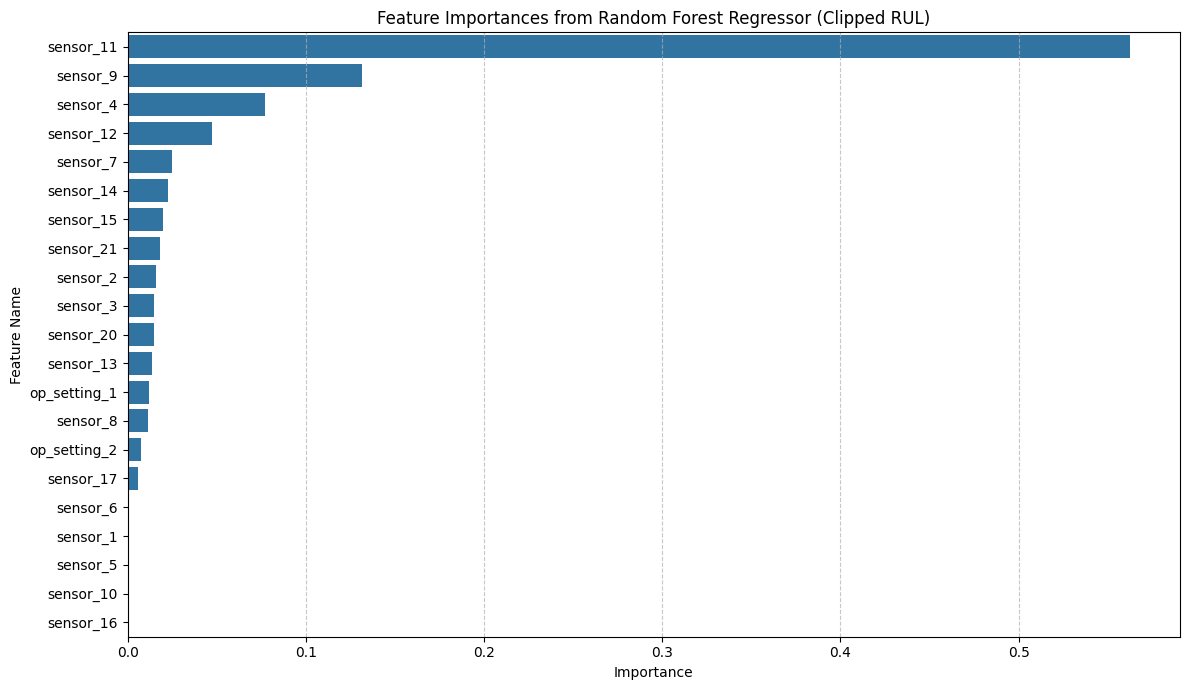

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
feature_importances = model_pro.feature_importances_

# Create a DataFrame for better visualization
# The 'features' list contains the names of the columns used for training X_train_clipped
importance_df = pd.DataFrame({
    'Feature': X_train_clipped.columns,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances:")
display(importance_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from Random Forest Regressor (Clipped RUL)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

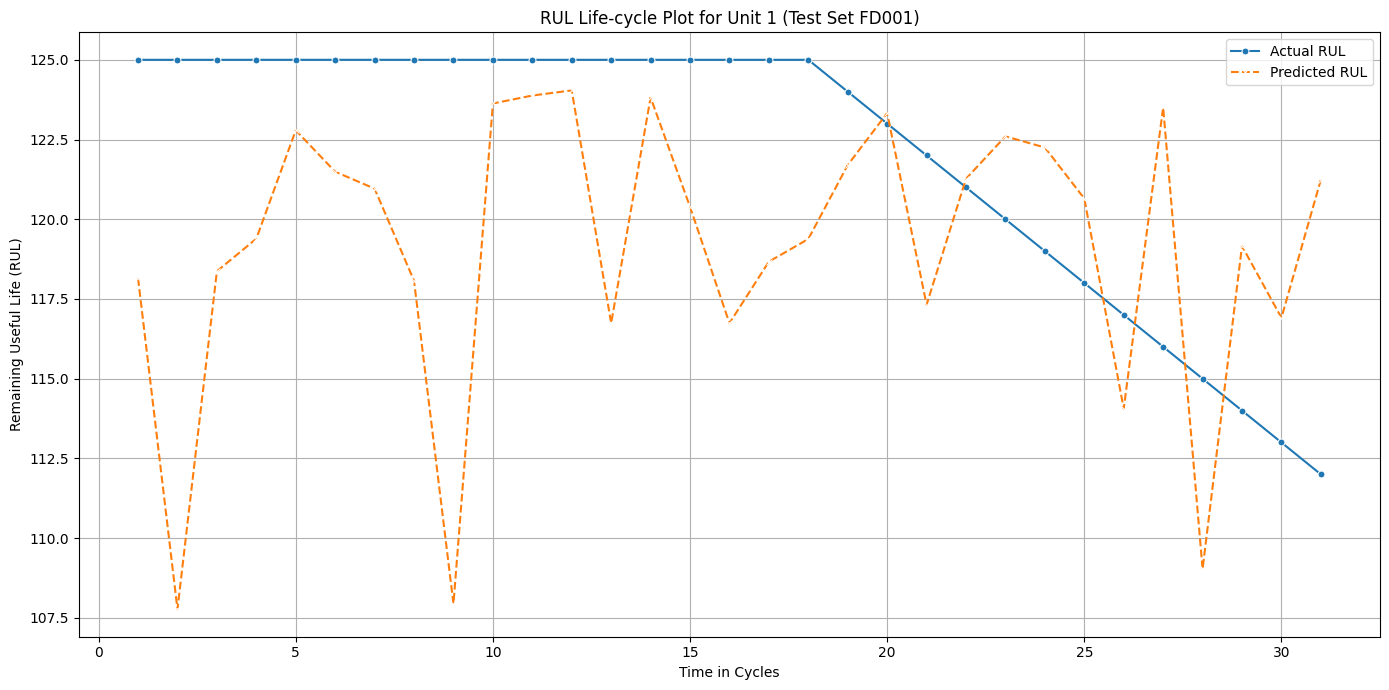

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Choose a specific unit number and dataset for plotting
plot_unit_number = 1
plot_dataset_index = 0 # Corresponds to FD001

# Reload and preprocess the specific test dataset (FD001 in this case)
# This ensures we have the raw data and can apply the correct preprocessing steps
test_file_path_for_plot = test_files[plot_dataset_index]
rul_file_path_for_plot = rul_files[plot_dataset_index]

df_test_plot = load_and_process_test_file(test_file_path_for_plot, rul_file_path_for_plot, columns)

# Apply preprocessing steps (dropping constant sensors, scaling, RUL clipping)
df_test_plot_processed = df_test_plot.copy()
df_test_plot_processed.drop(columns=dead_sensors, inplace=True, errors='ignore')

# Scale features using the *fitted* scaler from training data
current_features_plot = [col for col in df_test_plot_processed.columns if col not in ['unit_number', 'time_in_cycles', 'RUL']]
df_test_plot_processed[current_features_plot] = scaler.transform(df_test_plot_processed[current_features_plot])

# Clip RUL at 125, consistent with training
df_test_plot_processed['RUL_Clipped'] = df_test_plot_processed['RUL'].clip(upper=125)

# Extract features (X) and clipped target (y) for the selected unit
X_plot = df_test_plot_processed[df_test_plot_processed['unit_number'] == plot_unit_number][current_features_plot]
y_actual_plot = df_test_plot_processed[df_test_plot_processed['unit_number'] == plot_unit_number]['RUL_Clipped']

# Make predictions for the selected unit using the trained model (model_pro)
y_pred_plot = model_pro.predict(X_plot)

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Time in Cycles': df_test_plot_processed[df_test_plot_processed['unit_number'] == plot_unit_number]['time_in_cycles'],
    'Actual RUL': y_actual_plot,
    'Predicted RUL': y_pred_plot
})

# Plot the RUL life-cycle
plt.figure(figsize=(14, 7))
sns.lineplot(data=plot_df, x='Time in Cycles', y='Actual RUL', label='Actual RUL', marker='o', markersize=5)
sns.lineplot(data=plot_df, x='Time in Cycles', y='Predicted RUL', label='Predicted RUL', marker='x', markersize=5, linestyle='--')

plt.title(f'RUL Life-cycle Plot for Unit {plot_unit_number} (Test Set FD001)')
plt.xlabel('Time in Cycles')
plt.ylabel('Remaining Useful Life (RUL)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
import joblib

# Save the model to a file
joblib.dump(model_pro, 'turbine_pdm_model.pkl')
print("Trained model 'turbine_pdm_model.pkl' saved successfully.")

# Save the scaler as well (crucial for new data!)
joblib.dump(scaler, 'min_max_scaler.pkl')
print("MinMaxScaler 'min_max_scaler.pkl' saved successfully.")

Trained model 'turbine_pdm_model.pkl' saved successfully.
MinMaxScaler 'min_max_scaler.pkl' saved successfully.


In [31]:
readme_content = """
# Predictive Maintenance Project: Remaining Useful Life (RUL) Prediction

## Overview
This project focuses on predicting the Remaining Useful Life (RUL) of aircraft engines using sensor data. We developed a machine learning model to forecast how many more operational cycles an engine can perform before failure. This helps in scheduling maintenance proactively, reducing downtime, and improving safety.

## Dataset
We used the NASA Commercial Modular Aero-Propulsion System Simulation (C-MAPSS) dataset, specifically the FD001 subset for initial model development, and then evaluated on FD001, FD002, FD003, and FD004. Each dataset contains multivariate time series from a fleet of engines, including operational settings and various sensor measurements.

## Project Steps

1.  **Data Loading & Initial Exploration:** Loaded `train_FD001.txt` and assigned clear column names based on the provided `readme.txt` description.
2.  **RUL Calculation:** Calculated the RUL for each engine unit by subtracting the current cycle from its maximum observed cycle.
3.  **Data Preprocessing:**
    *   **Feature Cleaning:** Identified and removed constant (zero-variance) features such as `op_setting_3`, `sensor_18`, and `sensor_19` as they provide no useful information.
    *   **Feature Scaling:** Applied `MinMaxScaler` to scale all operational settings and sensor measurements to a range between 0 and 1. This prevents features with larger numerical values from dominating the model.
    *   **Data Split:** Divided the preprocessed data into features (X) and target (y).
4.  **Model Training (Random Forest Regressor):**
    *   An initial Random Forest Regressor model was trained, yielding an R-squared of 0.62.
5.  **RUL Clipping for Improved Performance:**
    *   To enhance prediction accuracy, the RUL target was clipped at a maximum of 125 cycles. This significantly improved model performance.
    *   Retraining the model with clipped RUL resulted in:
        *   **Mean Absolute Error (MAE): 13.60** (Improved from 29.62)
        *   **Root Mean Squared Error (RMSE): 18.78** (Improved from 41.48)
        *   **R-squared (R2): 0.79** (Improved from 0.62)
6.  **Feature Importance Analysis:** Explored which sensors the Random Forest model considered most important for RUL prediction. `Sensor_11` was identified as the most critical feature.
7.  **RUL Life-cycle Visualization:** Plotted the actual vs. predicted RUL for a sample engine unit to visually assess the model's tracking of degradation over time.
8.  **Model Evaluation on Multiple Datasets:** Tested the model's generalization across all four FD datasets (FD001, FD002, FD003, FD004). The model performed well on FD001 and FD003 but showed lower generalization to FD002 and FD004, likely due to their more complex operating conditions as described in the dataset's original `readme.txt`.
9.  **Model Saving:** Saved the trained Random Forest model (`turbine_pdm_model.pkl`) and the `MinMaxScaler` (`min_max_scaler.pkl`) for future use and deployment.

## Conclusion
This project successfully demonstrates a pipeline for RUL prediction using machine learning, highlighting the importance of data preprocessing and target clipping for robust performance. The feature importance analysis provides actionable insights into critical sensors for engine health monitoring.

## Future Work
*   Investigate strategies for improving generalization across diverse operating conditions (FD002, FD004).
*   Explore advanced feature engineering techniques.
*   Implement hyperparameter tuning for further model optimization.
"""

# Save the README content to a file
with open('README.md', 'w') as f:
    f.write(readme_content)

print("README.md file created successfully! You can download it from the file browser.")


README.md file created successfully! You can download it from the file browser.
